## Clasificación y Optimización de Hiperparámetros (Core)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import (train_test_split, GridSearchCV, cross_val_score, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_curve, roc_auc_score)

In [2]:
df = pd.read_csv('insurance.csv')

In [3]:
print("Primeras filas del DataFrame:")
display(df.head(10))

print("Ultimas filas del DataFrame:")
print(df.tail(5))

print("Informacion del DataFrame:")
print(df.info())

print("Dimension del DataFrame:")
print(df.shape)

Primeras filas del DataFrame:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


Ultimas filas del DataFrame:
      age     sex    bmi  children smoker     region     charges
1333   50    male  30.97         3     no  northwest  10600.5483
1334   18  female  31.92         0     no  northeast   2205.9808
1335   18  female  36.85         0     no  southeast   1629.8335
1336   21  female  25.80         0     no  southwest   2007.9450
1337   61  female  29.07         0    yes  northwest  29141.3603
Informacion del DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None
Dimension del DataFrame:
(1338, 7)


In [4]:
print("Estadisticas descriptivas del DataFrame:")
print(df.describe())

Estadisticas descriptivas del DataFrame:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


In [5]:
print("Tipos originales:")
print(df.dtypes)

Tipos originales:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


In [6]:
n_duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {n_duplicados}")

Filas duplicadas: 1


In [7]:
print("Verificacion de datos nulos:")
print(df.isnull().sum())

Verificacion de datos nulos:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


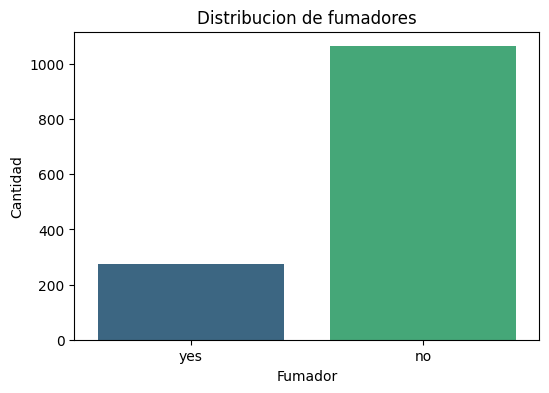

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='smoker', hue='smoker', palette='viridis')
plt.title('Distribucion de fumadores')
plt.xlabel('Fumador')
plt.ylabel('Cantidad')
plt.show()

In [9]:
df['high_cost'] = np.where(df['charges'] > df['charges'].median(), 1, 0)

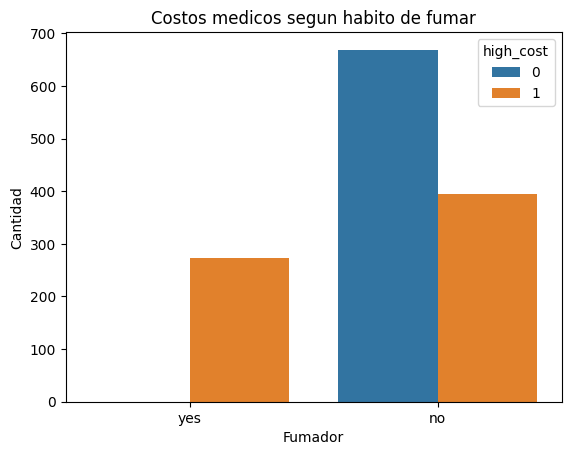

In [10]:
sns.countplot(data=df, x='smoker', hue='high_cost')
plt.title('Costos medicos segun habito de fumar')
plt.xlabel('Fumador')
plt.ylabel('Cantidad')
plt.show()

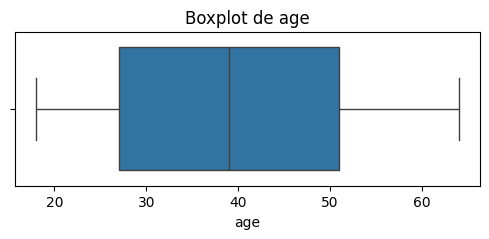

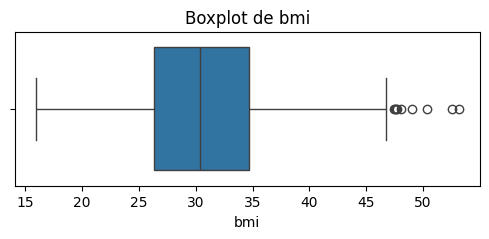

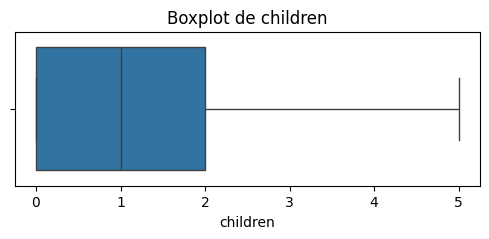

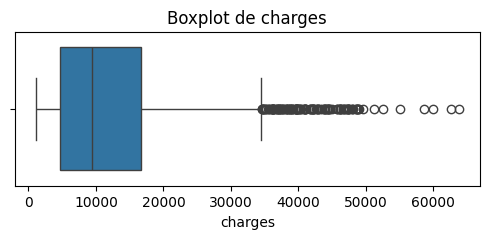

In [11]:
num_cols = ['age', 'bmi', 'children', 'charges']

for col in num_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)
    plt.show()

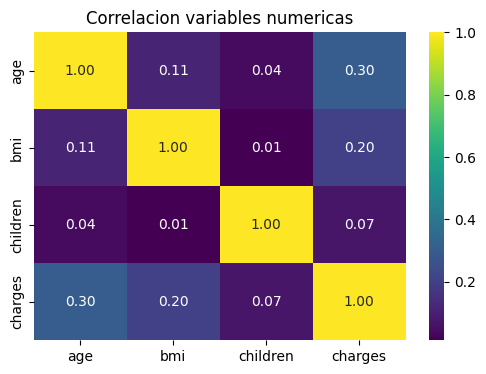

In [12]:
corr = df[['age', 'bmi', 'children', 'charges']].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='viridis', fmt='.2f')
plt.title('Correlacion variables numericas')
plt.show()

**Conclusiones EDA**

El dataset Medical Cost Personal Dataset contiene informacion de 1.338 individuos y tiene como objetivo analizar los factores que influyen en los costos de seguros medicos. Las variables incluidas corresponden a caracteristicas demograficas y de salud de los asegurados.

Las variables disponibles son:
age: edad del asegurado.
sex: sexo del asegurado.
bmi: indica de masa corporal.
children: numero de hijos o dependientes cubiertos por el seguro.
smoker: indica si la persona fuma o no.
region: regio geografica de residencia.
charges: costo medico anual asociado al asegurado.

Durante la exploracion inicial no se identificaron valores faltantes, por lo que no fue necesario realizar imputaciones. Sin embargo, se observo la presencia de valores atipicos (outliers) principalmente en las variables bmi y charges, los cuales fueron considerados durante el analisis.

Graficos

Distribucion de fumadores, el grafico muestra la cantidad de personas fumadoras y no fumadoras presentes en el dataset. Se observa una clara predominancia de personas no fumadoras. Aproximadamente el 80% de los registros corresponden a individuos que no fuman, mientras que una proporcion considerablemente menor corresponde a fumadores. Esta distribucion indica que el habito de fumar no es una caracteristica frecuente dentro de la muestra analizada. Sin embargo, debido a su posible impacto en los costos medicos, esta variable podria tener una alta relevancia predictiva.

Costos medicos segun habito de fumar, el grafico muestra la relacion entre la condicion de fumador y la variable creada 'high_cost, donde 0 es costo medico bajo y 1 es costo medico alto. Se observa que practicamente todos los fumadores se concentran en la categoria de costos altos. Por otro lado, los no fumadores presentan una mayor proporcion de costos bajos, aunque tambien existe un grupo importante con costos elevados. El habito de fumar parece ser uno de los factores mas influyentes en los costos medicos. Esta relacion sugiere que la variable smoker tendra una alta importancia dentreo de los modelos de clasificacion.

Boxplot
Edad, el grafico muestra la distribucion de las edades de los individuos. La mediana se encuentra cercana a los 39 años y la distribucion presenta una dispersion relativamente uniforme entre los 18 y los 64 años. No se observan valores atipicos significativos. La variable edad presenta una distribucion equilibrada y sin anomalias importantes, por lo que no requiere tratamientos especiales durante el preprocesamiento.

BMI, este grafico presenta la distribucion del indice de masa corporal de los individuos. La mayor concentrancion de valores se encuentra entre 26 y 35 puntos de BMI. Se identifican varios valores atipicos por encima de 47. La presencia de personas con indices de masa corporal extremadamente altos podria influir en el incremento de los costos medicos y aportar informacion relevante para los modelos predictivos.

Children, el grafico muestra la distribucion de la cantidad de hijos o dependientes. La mayoria de los individuos posee entre 0 y 2 hijos. No se observan valores atipicos significativos. La variable presenta una distribucion discreta y relativamente concentrada, por lo que su impacto en los costos medicos podria ser menor en comparacion con otras variables.

Charges, este grafico representa la distribucion de los costos medicos. La distribucion presenta una fuerte asimetria positiva. Se observan numerosos valores atipicos con costos muy superiores al promedio, alcanzando montos cercanos a los 65.000 dolares. Los costos medicos presentan una gran variabilidad entre individuos. La presencia de numerosos outliers sugiere que ciertos factores especificos generan gastos considerablemente mayores, siendo un aspecto clave para la construccion de modelos predictivos.

Mapa de correlacion
El mapa de calor muestra las correlaciones entre las variables numericas del dataset. La edad presenta la mayor asociacion lineal con los costos medicos, seguida por el indice de masa corporal. Sin embargo, ninguna de las variables numericas explica por si sola los costos medicos, lo que sugiere que variables categoricas como smoker podrian tener un papel mas importante en la prediccion.

Conclusiones generales.
El dataset presenta buena calidad de datos, ya que no contiene valores faltantes y requiere un preprocesamiento minimo. Se identificaron valores atipicos principalmente en las variables bmi y charges, siendo especialmente notorios en los costos medicos. El habito de fumar muestra una relacion evidente con los costos medicos altos, lo que indica que esta variable probablemente sera una de las mas relevantes para los modelos de clasificacion. Las variables numericas presentan correlaciones moderadas o bajas con los costos medicos, destacando unicamente la edad y el indica de masa corporal.
La distribucion de los costos medicos evidencia una alta variabilidad entre individuos, lo que justifica la necesidad de utilizar tecnicas de machine learning para identificar patrones asociados a costos elevados.
Los hallazgos del analisis exploratorio sugieren que variables como smker, age y bmi sera determinantes en la clasificacion de individuos con costos medicos altos y bajos.

In [13]:
X = df.drop(['charges', 'high_cost'], axis=1)
y = df['high_cost']

In [14]:
num_features = ['age', 'bmi', 'children']
cat_features = ['sex', 'smoker','region']

numeric_transform = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])

categorical_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocesador = ColumnTransformer([('num', numeric_transform, num_features), ('cat', categorical_transformer, cat_features)])

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
log_model = Pipeline([('prep', preprocesador), ('model', LogisticRegression())])

In [17]:
knn_model = Pipeline([('prep', preprocesador), ('model', KNeighborsClassifier())])

In [18]:
tree_model = Pipeline([('prep', preprocesador), ('model', DecisionTreeClassifier(random_state=42))])

In [19]:
for model, name in [(log_model, 'Logistic'), (knn_model, 'KNN'), (tree_model, 'Decision Tree')]:
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    print(name)
    print(scores.mean())

Logistic
0.908411214953271
KNN
0.8934579439252337
Decision Tree
0.8794392523364485


In [32]:
param_grid_log = {'model__C': np.logspace(-3,3,7), 'model__solver': ['liblinear', 'saga'], 'model__max_iter': [500, 1000, 2000]}

grid_log = GridSearchCV(log_model, param_grid=param_grid_log, cv=5, scoring='f1', n_jobs=-1)
grid_log.fit(X_train,y_train)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The ma

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': array([1.e-03...e+02, 1.e+03]), 'model__max_iter': [500, 1000, ...], 'model__solver': ['liblinear', 'saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter c

In [33]:
param_grid_knn = {'model__n_neighbors': [3,5,7,9,11,13], 'model__weights': ['uniform', 'distance'], 'model__metric': ['euclidean', 'manhattan']}

grid_knn = GridSearchCV(knn_model, param_grid_knn, cv=5, scoring='f1', n_jobs=-1)
grid_knn.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__metric': ['euclidean', 'manhattan'], 'model__n_neighbors': [3, 5, ...], 'model__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter

In [34]:
param_grid_tree = {'model__criterion': ['gini', 'entropy'], 'model__max_depth': [3,5,7,10,None], 'model__min_samples_split': [2,5,10], 'model__min_samples_leaf': [1,2,4]}

grid_tree = GridSearchCV(tree_model, param_grid_tree, cv=5, scoring='f1', n_jobs=-1)
grid_tree.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__criterion': ['gini', 'entropy'], 'model__max_depth': [3, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation 

In [35]:
random_log = RandomizedSearchCV(log_model, param_distributions=param_grid_log, n_iter=20, cv=5, scoring='f1', random_state=42, n_jobs=-1)
random_log.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__C': array([1.e-03...e+02, 1.e+03]), 'model__max_iter': [500, 1000, ...], 'model__solver': ['liblinear', 'saga']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchang

In [36]:
random_knn = RandomizedSearchCV(knn_model, param_distributions=param_grid_knn, n_iter=15, cv=5, scoring='f1', random_state=42, n_jobs=-1)
random_knn.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__metric': ['euclidean', 'manhattan'], 'model__n_neighbors': [3, 5, ...], 'model__weights': ['uniform', 'distance']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versioncha

In [37]:
random_tree = RandomizedSearchCV(tree_model, param_distributions=param_grid_tree, n_iter=20, cv=5, scoring='f1', random_state=42, n_jobs=-1)
random_tree.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__criterion': ['gini', 'entropy'], 'model__max_depth': [3, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies tha

In [38]:
comparacion = pd.DataFrame({'Modelo': ['Logistic Grid', 'Logistic Random', 'KNN Grid', 'KNN Random', 'Tree Grid', 'Tree Random'], 'F1': [grid_log.best_score_, random_log.best_score_, grid_knn.best_score_, random_knn.best_score_, grid_tree.best_score_, random_tree.best_score_]})
comparacion.sort_values('F1', ascending=False)


,Modelo,F1
4,Tree Grid,0.915481
5,Tree Random,0.914376
1,Logistic Random,0.908620
0,Logistic Grid,0.908620
2,KNN Grid,0.898394
3,KNN Random,0.896904


In [39]:
resultados = []

modelos = {'Logistic Grid': grid_log.best_estimator_, 'Logistic Random': random_log.best_estimator_, 'KNN Grid': grid_knn.best_estimator_, 'KNN Random': random_knn.best_estimator_, 'Decision Grid': grid_tree.best_estimator_, 'Decision Random': random_tree.best_estimator_}

for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:,1]
    resultados.append({'Modelo': nombre, 'Accuracy': accuracy_score(y_test, y_pred), 'Precision': precision_score(y_test, y_pred), 'Recall': recall_score(y_test, y_pred), 'F1-Score': f1_score(y_test, y_pred), 'ROC-AUC': roc_auc_score(y_test, y_prob)})

tabla_resultados = pd.DataFrame(resultados)
tabla_resultados.sort_values(by='F1-Score', ascending=False)
tabla_resultados



,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Grid,0.899254,0.884892,0.917910,0.901099,0.942526
1,Logistic Random,0.899254,0.884892,0.917910,0.901099,0.942526
2,KNN Grid,0.910448,0.936508,0.880597,0.907692,0.948318
3,KNN Random,0.899254,0.928000,0.865672,0.895753,0.947455
4,Decision Grid,0.932836,0.975410,0.888060,0.929688,0.938683
5,Decision Random,0.932836,0.975410,0.888060,0.929688,0.938683


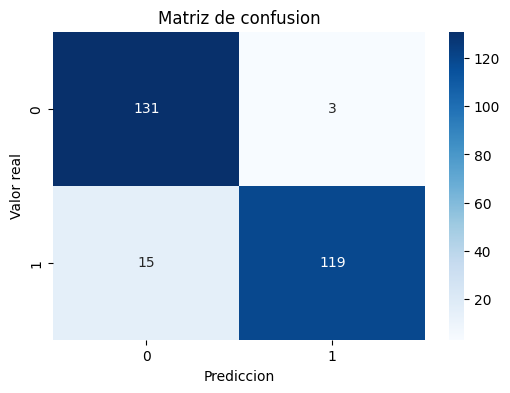

In [40]:
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusion')
plt.xlabel('Prediccion')
plt.ylabel('Valor real')
plt.show()

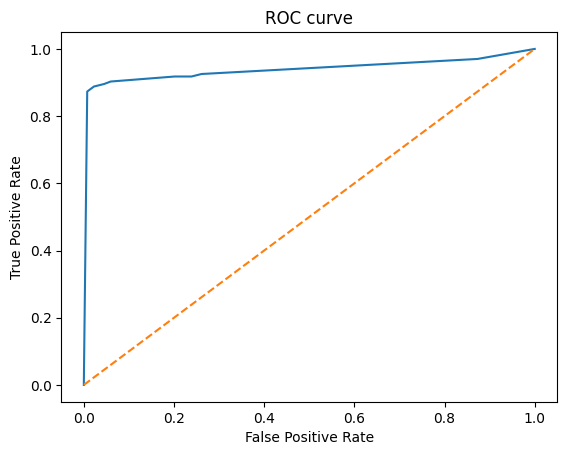

In [41]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title('ROC curve')
plt.show()

**Preprocesamiento de datos**

El dataset original fue diseñado para un problema de regresion, ya que la variable charges representa un valor numerico continuo correspondiente al costo medico anual. Sin embargo, el objetivo de este proyecto era desarrollar modelos de clasificacion, por lo que fue necesario transformar la variable continua en una variable categorica binaria denominada high_cost, fue creada utilizando la mediana de los costos medicos como punto de corte; 0 es costo medico bajo, 1 costo medico alto. Esta transformacion permitio convertir el problema original de regresion en un problema de clasificacion binaria, manteniendo ademas un conjuto de clases equilibrado, ya que la mediana divide aproximadamente los datos en dos grupos de tamaño similar.

Antes de entrenar los modelos de clasificacion fue neceario realizar una etapa de preprocesamiento para asegurar que los datos estuvieron en un formato adecuado para los algoritmos de machine learning.
Las variables categoricas (sex, smoker y region) fueron transformadas mediante Onehotencoding, convirtiendo cada categoria en variables binarias para que pudieran ser interpretadas por los algoritmos de clasificacion. Las variables numericas (age, bmi y children) fueron estandarizadas utilizando Standarscaler, permitiendo que todas las variables se encontraran en una escala comparable y evitando que aquellas con valores mas altos dominaran el proceso de aprendizaje.

El conjunto de datos fue dividido en 80% para entrenamiento y 20% para prueba esto permitio evaluar posteriormente el desempeño de los modelos sobre datos no vistos durante el entrenamiento.

Se implementaron los modelos Regresion logistica, KNN y Arbol de decision. La evaluacion inicial mediante validacion cruzada mostro que la regresion logistica obtuvo el mejor rendimiento (0.908), seguida por KNN (0.893) y arbol de decision (0.879). Sin embargo, tras aplicar tecnicas de optimizacion de hiperparametros mediante GridSearchCV y RandomizedSearchCV, el arbol de decision mejoro considerablemente su desempeño, aunque KNN obtuvo el valor mas alto de ROC-AUC (0.948), el arbol de decision presento mejores resultados en Accuracy, Precision, F1-Score, metricas que representan de mejor manera el equilibrio entre errores de clasificacion y capacidad predictiva. Ademas, GridSearchCV y RandomizedSearchCV obtuvieron exactamente los mismos resultados para el arbol de decision, indicando que ambos metodos encontraron una configuracion optima muy similar. Esto evidencia la importancia de la optimizacion de hiperparametros para maximizar la capacidad predictiva de los modelos de clasificacion.
Por estas razones, el Arbol de decision fue seleccionado como modelo final.

Matriz de confusion
La matriz de confusion obtenida para el modelo seleccionado muestra que 131 casos de costos bajos fueron correctamente clasificados, 119 casos de costos altos fueron correctamente identificados, solo 3 casos fueron clasificados erroneamente como costos altos cuando realmente eran bajos y 15 casos de costos altos fueron clasificados como bajos. Estos resultados evidencian una alta capacidad de clasificacion del modelo y una baja tasa de error general.

Analisis de la curva ROC
Se observa que la curva se encuentra considerablemente por encima de la linea diagonañ de referencia, que representa una clasificacion aleatoria. El modelo alcanza un valor de ROC-AUC = 0.939, indicando una excelente capacidad para distinguir entre individuos con costos medicos altos y bajos. El valor cercano a 1 refleja una alta calidad predictiva.

Conclusiones generales
El dataset presento una buena calidad de datos, sin valores faltantes. Fue necesario transformar la variable continua charges en una varible binaria (high_cost) para adaptar el problema a un escenario de clasificacion.
El analisis exploratorio permitio identificar que varibles como smoker, age y bmi tienen una influencia importante sobre los costos medicos. La optimizacion mediante GridSearchCV y RandomizedSearchCV permitio mejorar el rendimiento de los modelos y comparar diferentes configuraciones de hiperparametros. El arbol de decision obtuvo el mejor desempeño general, alcanzando un F1-Score de 0.930 y una exactitud superior al 90%. La matriz de confusion mostro una baja cantidad de errores de clasificacion, mientras que la curva ROC confirmo una excelente capacidad de discriminacion entre las clases. Los resultados obtenidos demuestran que las caracteristicas demograficas y de salud incluidas en el dataset permiten predecir con alta precision si un individuo tendra costos medicos altos o bajos.